# 一、环境配置

In [29]:
!pip install torch transformers peft datasets scikit-learn matplotlib seaborn pandas tqdm

## 1.1 设备配置

In [30]:
# 检查 GPU 是否可用
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## 1.2 路径配置

In [31]:
import os
from pathlib import Path

# 项目根目录
PROJECT_ROOT=Path("/kaggle/working")
# 数据根目录
DATA_ROOT=Path("/kaggle/input/datasets/kintsugi0v0/dimabsa")

# 中文数据集文件路径（繁体中文 - 餐厅领域）
TRAIN_FILE = DATA_ROOT / "zho_restaurant_train_alltasks.jsonl"
DEV_FILE = DATA_ROOT / "zho_restaurant_dev_task1.jsonl"
TEST_FILE = DATA_ROOT / "zho_restaurant_test_task1.jsonl"

print(f"Data path: {DATA_ROOT}")
print(f"Train: {TRAIN_FILE.exists()}, Dev: {DEV_FILE.exists()}, Test: {TEST_FILE.exists()}")

Data path: /kaggle/input/datasets/kintsugi0v0/dimabsa
Train: True, Dev: True, Test: True


## 1.3 数据示例
中文数据样例  
数据来自台湾餐厅评论（繁体中文）  
示例文本: "經典黃悶魷魚好吃！酸湯的也很不錯，但對我來說有點太辣。"  
方面词: "黃悶魷魚", "酸湯"  
VA分数: 6.75#5.75 (Valence=6.75, Arousal=5.75)

# 二、数据探索与预处理

## 2.1 绘图参数的设置

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图参数
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (8, 6),
    'font.family': 'serif'
})

# 常用颜色
ACL_COLORS = {
    'blue': '#3175B0',      # 主蓝色
    'orange': '#E69C2E',    # 橙色
    'red': '#CC3333',       # 红色
    'green': '#4C8C2B',     # 绿色
    'purple': '#7654A0',    # 紫色
    'gray': '#666666',      # 灰色
}

## 2.2 数据样例

In [33]:
import json
import pandas as pd
import numpy as np
from collections import Counter

def load_jsonl(file_path):
    data=[]
    with open(file_path,'r',encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data=load_jsonl(TRAIN_FILE)
dev_data=load_jsonl(DEV_FILE)

print(f"训练集样本数: {len(train_data)}")
print(f"验证集样本数: {len(dev_data)}")
print(f"\n中文数据示例:")
print(json.dumps(train_data[0], indent=2, ensure_ascii=False))

# 中文数据样例解读
print("\n" + "="*50)
print("中文数据字段说明:")
print("="*50)
print(f"ID: {train_data[0]['ID']}")
print(f"Text: {train_data[0]['Text']}")
print(f"Quadruplet: {train_data[0]['Quadruplet']}")
print("  - Aspect:   方面词（评价对象）")
print("  - Category: 方面类别")
print("  - Opinion:  观点词")
print("  - VA:       Valence#Arousal（效价#唤醒度）")

训练集样本数: 6050
验证集样本数: 300

中文数据示例:
{
  "ID": "R0283:S003",
  "Text": "肉粿沒有很焦脆。",
  "Quadruplet": [
    {
      "Aspect": "肉粿",
      "Category": "FOOD#QUALITY",
      "Opinion": "沒有很焦脆",
      "VA": "4.00#5.00"
    }
  ]
}

中文数据字段说明:
ID: R0283:S003
Text: 肉粿沒有很焦脆。
Quadruplet: [{'Aspect': '肉粿', 'Category': 'FOOD#QUALITY', 'Opinion': '沒有很焦脆', 'VA': '4.00#5.00'}]
  - Aspect:   方面词（评价对象）
  - Category: 方面类别
  - Opinion:  观点词
  - VA:       Valence#Arousal（效价#唤醒度）


## 2.3 数据统计分析

In [34]:
import jieba


def analyze_data(data,verbose=False):
    """
    分析数据分布

    Args:
        data: load_jsonl 读出来的数据
        verbose: 是否打印脏数据警告
    
    returns:
    - valence_scores: Valence 分数列表
    - arousal_scores: Arousal 分数列表  
    - text_lengths: 文本长度列表
    - aspect_lengths: 方面词长度列表
    - opinion_lengths: 观点词分词数 
    - num_aspects_per_sample: 每个样本的方面词数量
    """
    valence_scores = []
    arousal_scores = []
    text_lengths = []
    aspect_lengths = []
    opinion_lengths = []   
    num_aspects_per_sample = []
    skipped=0
    
    for item in data:
        text = item['Text']
        text_lengths.append(len(list(jieba.cut(text))))
        
        quads=item.get('Quadruplet',[])
        num_aspects_per_sample.append(len(quads))
        
        for av in quads:
            try:
                v, a = map(float, av['VA'].split('#'))
            except (KeyError, ValueError, AttributeError) as e:
                skipped += 1
                if verbose:
                    print(f"[跳过] ID={item.get('ID')}  VA={av.get('VA')}  err={e}")
                continue
                
            valence_scores.append(v)
            arousal_scores.append(a)
            aspect_lengths.append(len(list(jieba.cut(av['Aspect']))))
            opinion_lengths.append(len(list(jieba.cut(av['Opinion']))))
    
    if skipped:
        print(f"⚠️ 共跳过 {skipped} 条脏数据")
    
    # 转成 numpy，方便后面算统计量
    return {
        'valence':        np.array(valence_scores),
        'arousal':        np.array(arousal_scores),
        'text_len':       np.array(text_lengths),
        'aspect_len':     np.array(aspect_lengths),
        'opinion_len':    np.array(opinion_lengths),
        'num_aspects':    np.array(num_aspects_per_sample),
    }

def print_stats(stats, name="训练集"):
    """把统计信息打印出来"""
    print(f"\n{'='*55}\n【{name}】分布统计\n{'='*55}")
    
    # 数值类指标
    for k in ['valence', 'arousal', 'text_len', 'aspect_len', 'opinion_len', 'num_aspects']:
        arr = stats[k]
        if arr.size == 0:
            print(f"  {k:12s}  空")
            continue
        print(f"  {k:12s}  n={arr.size:5d}  "
              f"min={arr.min():6.2f}  max={arr.max():6.2f}  "
              f"mean={arr.mean():6.2f}  std={arr.std():6.2f}  "
              f"median={np.median(arr):6.2f}")
    
    # 额外：每条样本四元组数量分布
    cnt = Counter(stats['num_aspects'].tolist())
    print(f"\n  每条样本的四元组数量分布: {dict(sorted(cnt.items()))}")
    

train_data = load_jsonl(TRAIN_FILE)
dev_data   = load_jsonl(DEV_FILE)
print(f"训练集样本数: {len(train_data)}")
print(f"验证集样本数: {len(dev_data)}")
# 打印第一条，确认字段
print(f"\n第一条样本: ID={train_data[0]['ID']}")
print(f"  Text: {train_data[0]['Text']}")
print(f"  Quadruplet: {train_data[0]['Quadruplet']}")

# 分析
train_stats = analyze_data(train_data, verbose=True)
dev_stats   = analyze_data(dev_data,   verbose=True)
print_stats(train_stats, "训练集")
print_stats(dev_stats,   "验证集")

训练集样本数: 6050
验证集样本数: 300

第一条样本: ID=R0283:S003
  Text: 肉粿沒有很焦脆。
  Quadruplet: [{'Aspect': '肉粿', 'Category': 'FOOD#QUALITY', 'Opinion': '沒有很焦脆', 'VA': '4.00#5.00'}]

【训练集】分布统计
  valence       n= 8523  min=  1.50  max=  8.25  mean=  5.81  std=  0.99  median=  6.10
  arousal       n= 8523  min=  4.00  max=  8.25  mean=  5.76  std=  0.65  median=  5.67
  text_len      n= 6050  min=  2.00  max= 40.00  mean=  9.16  std=  4.63  median=  8.00
  aspect_len    n= 8523  min=  1.00  max=  9.00  mean=  1.74  std=  1.00  median=  1.00
  opinion_len   n= 8523  min=  1.00  max=  7.00  mean=  1.79  std=  0.83  median=  2.00
  num_aspects   n= 6050  min=  1.00  max=  6.00  mean=  1.41  std=  0.69  median=  1.00

  每条样本的四元组数量分布: {1: 4165, 2: 1390, 3: 414, 4: 71, 5: 8, 6: 2}

【验证集】分布统计
  valence       空
  arousal       空
  text_len      n=  300  min=  6.00  max= 64.00  mean= 25.22  std= 13.40  median= 22.00
  aspect_len    空
  opinion_len   空
  num_aspects   n=  300  min=  0.00  max=  0.00  mean=  0.00  s

## 2.4 数据可视化分析

Figure saved to ./data_distribution.png


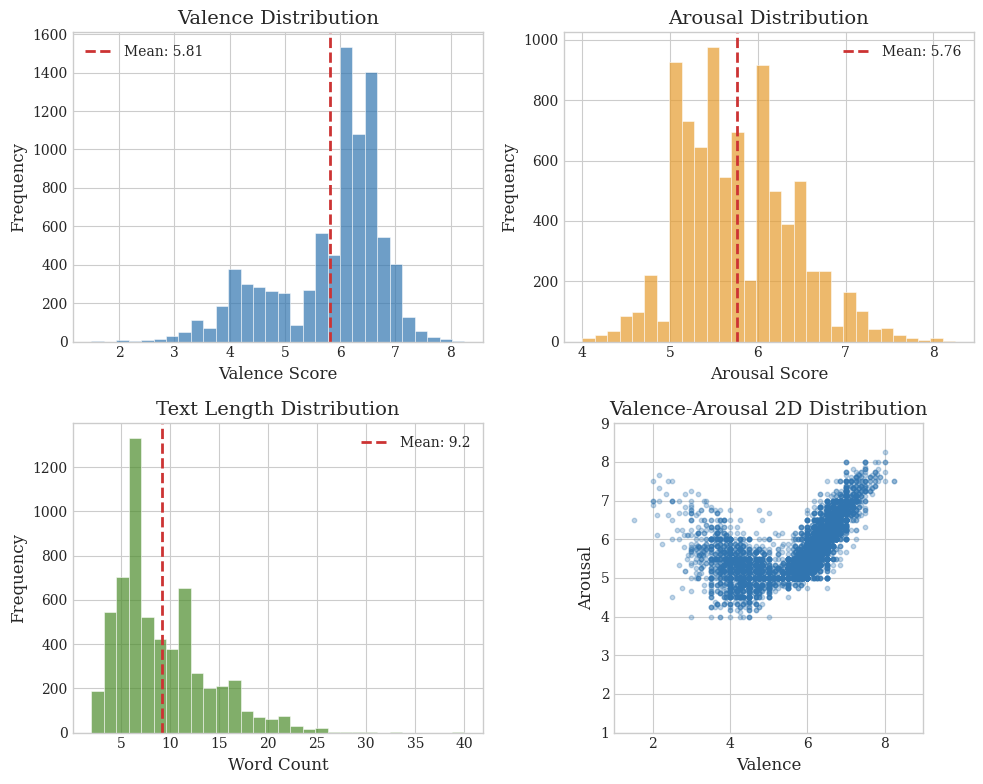

In [35]:
def plot_data_distribution(stats, save_path=None):
    """
    绘制数据分布图
    
    - 使用直方图展示连续值分布
    - 使用核密度估计 (KDE) 展示分布曲线
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    # 1. Valence 分布
    ax1 = axes[0, 0]
    ax1.hist(stats['valence'], bins=30, color=ACL_COLORS['blue'], 
             alpha=0.7, edgecolor='white', linewidth=0.5)
    ax1.set_xlabel('Valence Score')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Valence Distribution')
    ax1.axvline(np.mean(stats['valence']), color=ACL_COLORS['red'], 
                linestyle='--', linewidth=2, label=f'Mean: {np.mean(stats["valence"]):.2f}')
    ax1.legend()
    
    # 2. Arousal 分布
    ax2 = axes[0, 1]
    ax2.hist(stats['arousal'], bins=30, color=ACL_COLORS['orange'], 
             alpha=0.7, edgecolor='white', linewidth=0.5)
    ax2.set_xlabel('Arousal Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Arousal Distribution')
    ax2.axvline(np.mean(stats['arousal']), color=ACL_COLORS['red'], 
                linestyle='--', linewidth=2, label=f'Mean: {np.mean(stats["arousal"]):.2f}')
    ax2.legend()
    
    # 3. 文本长度分布
    ax3 = axes[1, 0]
    ax3.hist(stats['text_len'], bins=30, color=ACL_COLORS['green'], 
             alpha=0.7, edgecolor='white', linewidth=0.5)
    ax3.set_xlabel('Word Count')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Text Length Distribution')
    ax3.axvline(np.mean(stats['text_len']), color=ACL_COLORS['red'], 
                linestyle='--', linewidth=2, label=f'Mean: {np.mean(stats["text_len"]):.1f}')
    ax3.legend()
    
    # 4. VA 二维散点图
    ax4 = axes[1, 1]
    scatter = ax4.scatter(stats['valence'], stats['arousal'], 
                         alpha=0.3, c=ACL_COLORS['blue'], s=10)
    ax4.set_xlabel('Valence')
    ax4.set_ylabel('Arousal')
    ax4.set_title('Valence-Arousal 2D Distribution')
    ax4.set_xlim(1, 9)
    ax4.set_ylim(1, 9)
    ax4.set_aspect('equal')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

# 绘制训练集分布
plot_data_distribution(train_stats, save_path="./data_distribution.png")

## 2.5 预处理数据

In [36]:
import jieba

def explode_aspect_va(data, verbose=False):
    """
    将多方面词样本展开为单一样本
    
    为什么要展开：
    - 一个文本可能包含多个方面词（如 "Food and service are great"）
    - 每个 (Text, Aspect, Opinion, VA) 组合是一个独立的训练样本
    - 模型需要对每个方面词单独预测 VA
    
    数据来源：
    - 使用 Quadruplet 字段
    - 包含 Aspect（方面词）、Opinion（观点词）、VA（情感分数）
    - 使用 jieba 分词统计文本长度
    
    输入: {"Text": "...", "Quadruplet": [{"Aspect": "food", "Opinion": "great", "VA": "7.5#6.5"}, ...]}
    输出: [
        {"ID": "...", "Text": "...", "Aspect": "food", "Opinion": "great", "Valence": 7.5, "Arousal": 6.5},
        ...
    ]
    """
    exploded = []
    skipped = 0
    
    for item in data:
        text = item['Text']
        quads = item.get('Quadruplet', [])  # 使用 Quadruplet 字段
        
        for av in quads:
            try:
                # 解析 VA 分数
                v, a = map(float, av['VA'].split('#'))
                
                # 获取方面词和观点词
                aspect = av.get('Aspect', '')
                opinion = av.get('Opinion', '')
                
                exploded.append({
                    'ID': item['ID'],
                    'Text': text,
                    'Aspect': aspect,
                    'Opinion': opinion,
                    'Valence': v,
                    'Arousal': a
                })
            except (KeyError, ValueError, AttributeError) as e:
                skipped += 1
                if verbose:
                    print(f"[跳过] ID={item.get('ID')}  VA={av.get('VA')}  err={e}")
                continue
    
    if skipped:
        print(f"⚠️ 共跳过 {skipped} 条脏数据")
    
    return exploded

# 展开数据
train_exploded = explode_aspect_va(train_data, verbose=True)
dev_exploded = explode_aspect_va(dev_data, verbose=True)

print(f"展开前训练集: {len(train_data)} 样本")
print(f"展开后训练集: {len(train_exploded)} 样本")
print(f"展开前验证集: {len(dev_data)} 样本")
print(f"展开后验证集: {len(dev_exploded)} 样本")
print(f"\n展开后数据示例:")
print(json.dumps(train_exploded[0], indent=2, ensure_ascii=False))

展开前训练集: 6050 样本
展开后训练集: 8523 样本
展开前验证集: 300 样本
展开后验证集: 0 样本

展开后数据示例:
{
  "ID": "R0283:S003",
  "Text": "肉粿沒有很焦脆。",
  "Aspect": "肉粿",
  "Opinion": "沒有很焦脆",
  "Valence": 4.0,
  "Arousal": 5.0
}


# 3. 数据加载

## 3.1 Dataset实现

In [37]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer
from typing import Dict, List, Optional

class DimASRDataset(Dataset):
    """
    DimASR 任务数据集
    
    任务目标：给定文本 + Aspect，预测 VA (Valence-Arousal) 分数
    
    为什么继承 Dataset：
    - PyTorch 标准化接口，方便与 DataLoader 配合
    - 支持批量加载和并行预处理
    - 支持多种 tokenizer 和配置
    
    输入格式：
    - 输入: (Text, Aspect) 
    - 输入拼接方式: [CLS] text [SEP] aspect [SEP]
    
    数据字段（来自 explode_aspect_va）：
    - Text: 中文文本
    - Aspect: 方面词（评价对象）
    - Valence: 效价分数 (1.0-9.0)
    - Arousal: 唤醒度分数 (1.0-9.0)
    """
    
    def __init__(
        self,
        data: List[Dict],
        tokenizer: AutoTokenizer,
        max_length: int = 64,
        has_label: bool = True
    ):
        """
        Args:
            data: 展开后的数据列表（来自 explode_aspect_va）
            tokenizer: HuggingFace tokenizer（中文，如 hfl/chinese-roberta-wwm-ext）
            max_length: 最大序列长度（中文按字符计）
            has_label: 是否有标签（测试集为 False）
        """
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_label = has_label
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx) -> Dict[str, torch.Tensor]:
        """
        获取单个样本
        
        为什么要这样处理：
        1. 使用 text_pair 模式：主文本和方面词分别编码
        2. [CLS] text [SEP] aspect [SEP] 是标准 BERT 输入格式
        3. 中文 BERT 会自动处理中文分词
        """
        item = self.data[idx]
        
        # 编码：使用 aspect 作为 second text
        # 格式: [CLS] text [SEP] aspect [SEP]
        encoding = self.tokenizer(
            item['Text'],
            item['Aspect'],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        result = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
        }
        
        # 添加 token_type_ids（BERT 需要）
        if 'token_type_ids' in encoding:
            result['token_type_ids'] = encoding['token_type_ids'].squeeze(0)
        
        # 添加标签
        if self.has_label:
            result['labels'] = torch.tensor(
                [item['Valence'], item['Arousal']],
                dtype=torch.float
            )
        
        return result

def create_dataloader(
    dataset: Dataset,
    batch_size: int = 16,
    shuffle: bool = True,
    num_workers: int = 2
) -> torch.utils.data.DataLoader:
    """
    创建数据加载器
    
    """
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True  # 加速 GPU 传输
    )

## 3.2 Tokenizer的选择

In [38]:
# 中文 BERT 模型选择

# 中文预训练模型：
# 1. bert-base-chinese
# 2. hfl/chinese-bert-wwm-ext
# 3. hfl/chinese-roberta-wwm-ext
# 4. bertweet-base

# 本文档使用哈工大的 RoBERTa-wwm-ext，因其在中文任务上效果更佳
CHINESE_BERT_MODEL = 'hfl/chinese-roberta-wwm-ext'

def get_chinese_tokenizer(model_name=CHINESE_BERT_MODEL):
    """
    获取中文 tokenizer
    
    为什么用 RoBERTa-wwm-ext：
    - Whole Word Masking (WWM) 训练策略，中文效果更好
    - 哈工大在中文 NLP 领域有良好声誉
    - 预训练语料丰富，涵盖中文各领域
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    return tokenizer

# 测试中文分词
tokenizer = get_chinese_tokenizer()

# 测试样本
test_text = "經典黃悶魷魚好吃"
test_aspect = "黃悶魷魚"

tokens = tokenizer(test_text, test_aspect, return_tensors='pt')
print(f"文本: {test_text}")
print(f"方面词: {test_aspect}")
print(f"Token IDs: {tokens['input_ids']}")
print(f"解码: {tokenizer.decode(tokens['input_ids'][0])}")

文本: 經典黃悶魷魚好吃
方面词: 黃悶魷魚
Token IDs: tensor([[ 101, 5195, 1073, 7941, 2653, 7799, 7797, 1962, 1391,  102, 7941, 2653,
         7799, 7797,  102]])
解码: [CLS] 經 典 黃 悶 魷 魚 好 吃 [SEP] 黃 悶 魷 魚 [SEP]


## 3.3 Dataset的验证

In [39]:
# 加载中文 tokenizer
tokenizer = get_chinese_tokenizer()

# 创建数据集（中文）
train_dataset = DimASRDataset(train_exploded, tokenizer, max_length=128)
dev_dataset = DimASRDataset(dev_exploded, tokenizer, max_length=128)

# 测试获取样本
sample = train_dataset[0]
print("样本形状:")
print(f"  input_ids: {sample['input_ids'].shape}")
print(f"  attention_mask: {sample['attention_mask'].shape}")
print(f"  labels: {sample['labels']}")

# 解码查看
print(f"\n解码验证:")
print(f"  Text: {train_exploded[0]['Text']}")
print(f"  Aspect: {train_exploded[0]['Aspect']}")
print(f"  VA: {train_exploded[0]['Valence']}, {train_exploded[0]['Arousal']}")
decoded = tokenizer.decode(sample['input_ids'])
print(f"  Tokenized: {decoded}")

样本形状:
  input_ids: torch.Size([128])
  attention_mask: torch.Size([128])
  labels: tensor([4., 5.])

解码验证:
  Text: 肉粿沒有很焦脆。
  Aspect: 肉粿
  VA: 4.0, 5.0
  Tokenized: [CLS] 肉 粿 沒 有 很 焦 脆 。 [SEP] 肉 粿 [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


# 四、模型构建

In [40]:
import json
import random
import argparse
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer


# 超参数配置
CONFIG = {
    'seed': 42,
    'max_length': 128,
    'batch_size': 16,
    'learning_rate': 2e-5,
    'epochs': 3,
    'weight_decay': 0.01,
    'lr_head': 1e-3,          # Group C 标准: 回归头/附加头差分 lr
    'warmup_ratio': 0.1,      # Group C 标准: warmup + 线性衰减
    'dropout': 0.1,
}

# 实验配置
MODEL_CONFIGS = {
    'Exp-A1': {'encoder': 'hfl/chinese-bert-wwm-ext', 'type': 'base'},
    'Exp-A2': {'encoder': 'hfl/chinese-roberta-wwm-ext', 'type': 'base'},
    'Exp-A3': {'encoder': 'hfl/chinese-roberta-wwm-ext', 'type': 'cnn'},
    'Exp-A4': {'encoder': 'hfl/chinese-roberta-wwm-ext', 'type': 'lstm'},
}



print("配置完成!")
print(f"可用实验: {list(MODEL_CONFIGS.keys())}")


def set_seed(seed):
    """设置随机种子"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def explode_quadruplet(data):
    """
    展开训练集数据（使用 Quadruplet 字段）
    训练集格式: {"Text": "...", "Quadruplet": [{"Aspect": "...", "Opinion": "...", "Category": "...", "VA": "..."}]}
    """
    exploded = []
    for item in data:
        for q in item.get('Quadruplet', []):
            try:
                v, a = map(float, q['VA'].split('#'))
                exploded.append({
                    'Text': item['Text'],
                    'Aspect': q.get('Aspect', ''),
                    'Valence': v,
                    'Arousal': a
                })
            except:
                continue
    return exploded

def explode_aspect_va(data):
    """
    展开验证集数据（使用 Aspect_VA 字段）
    验证集格式: {"Text": "...", "Aspect_VA": [{"Aspect": "...", "VA": "..."}]}
    """
    exploded = []
    for item in data:
        for av in item.get('Aspect_VA', []):
            try:
                v, a = map(float, av['VA'].split('#'))
                exploded.append({
                    'Text': item['Text'],
                    'Aspect': av.get('Aspect', ''),
                    'Valence': v,
                    'Arousal': a
                })
            except:
                continue
    return exploded

print("工具函数定义完成")
print("- explode_quadruplet: 用于训练集 (Quadruplet 字段)")
print("- explode_aspect_va: 用于验证集 (Aspect_VA 字段)")

配置完成!
可用实验: ['Exp-A1', 'Exp-A2', 'Exp-A3', 'Exp-A4']
工具函数定义完成
- explode_quadruplet: 用于训练集 (Quadruplet 字段)
- explode_aspect_va: 用于验证集 (Aspect_VA 字段)


## 4.1 Bert-Base

In [52]:
class BERTRegressor(nn.Module):
    """
    BERT + Regression Head
    架构: BERT Encoder → [CLS] → Linear(768→2) → (Valence, Arousal)
    """
    
    def __init__(self, encoder_name, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(hidden_size, 2)
        
        nn.init.xavier_uniform_(self.regressor.weight, gain=0.5)
        nn.init.zeros_(self.regressor.bias)
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        pooled = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        pooled = self.dropout(pooled)
        va_pred = self.regressor(pooled)
        # STE clamp: 前向值截断到 [1,9](推理语义不变), 梯度按未截断透传。
        # 修复: 硬 clamp 区间外梯度为 0, 训练早期一旦越界即永久卡死在边界
        # (旧结果 4.9963/3.66/3.67 及 A/B 表大片同值均源于此)
        va_pred = va_pred + (va_pred.clamp(1.0, 9.0) - va_pred).detach()
        return va_pred

## 4.2 BERT+Cnn

In [42]:
class BERTCNNRegressor(nn.Module):
    """
    BERT + CNN 增强
    架构: BERT → CNN(多尺度) → Concat → Regression
    """
    
    def __init__(self, encoder_name, kernel_sizes=[3, 4, 5], num_filters=256, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        
        # 多尺度 CNN
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden_size, num_filters, k) for k in kernel_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        concat_size = hidden_size + len(kernel_sizes) * num_filters
        self.regressor = nn.Linear(concat_size, 2)
        
        nn.init.xavier_uniform_(self.regressor.weight, gain=0.5)
        nn.init.zeros_(self.regressor.bias)
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        hidden = outputs.last_hidden_state
        hidden_t = hidden.transpose(1, 2)  # (B, H, T)
        
        # CNN 特征
        conv_features = []
        for conv in self.convs:
            conv_out = torch.relu(conv(hidden_t))
            pooled = torch.max(conv_out, dim=2)[0]
            conv_features.append(pooled)
        
        conv_features = torch.cat(conv_features, dim=1)
        conv_features = self.dropout(conv_features)
        
        # [CLS] 特征
        cls_features = hidden[:, 0, :]
        cls_features = self.dropout(cls_features)
        
        # 拼接
        combined = torch.cat([cls_features, conv_features], dim=1)
        va_pred = self.regressor(combined)
        # STE clamp: 前向值截断到 [1,9](推理语义不变), 梯度按未截断透传。
        # 修复: 硬 clamp 区间外梯度为 0, 训练早期一旦越界即永久卡死在边界
        # (旧结果 4.9963/3.66/3.67 及 A/B 表大片同值均源于此)
        va_pred = va_pred + (va_pred.clamp(1.0, 9.0) - va_pred).detach()
        
        return va_pred

## 4.3 BERT + BiLSTM

In [43]:
class BERTLSTMRegressor(nn.Module):
    """
    BERT + BiLSTM 增强
    架构: BERT → BiLSTM → Concat → Regression
    """
    
    def __init__(self, encoder_name, hidden_size=256, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        encoder_hidden = self.encoder.config.hidden_size
        
        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=encoder_hidden,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0
        )
        
        self.dropout = nn.Dropout(dropout)
        lstm_output_size = hidden_size * 2  # bidirectional
        concat_size = encoder_hidden + lstm_output_size
        self.regressor = nn.Linear(concat_size, 2)
        
        nn.init.xavier_uniform_(self.regressor.weight, gain=0.5)
        nn.init.zeros_(self.regressor.bias)
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        hidden = outputs.last_hidden_state
        
        # BiLSTM
        lstm_out, (h_n, _) = self.lstm(hidden)
        forward_h = h_n[0]   # 正向
        backward_h = h_n[1]  # 反向
        lstm_features = torch.cat([forward_h, backward_h], dim=1)
        lstm_features = self.dropout(lstm_features)
        
        # [CLS] 特征
        cls_features = hidden[:, 0, :]
        cls_features = self.dropout(cls_features)
        
        # 拼接
        combined = torch.cat([cls_features, lstm_features], dim=1)
        va_pred = self.regressor(combined)
        # STE clamp: 前向值截断到 [1,9](推理语义不变), 梯度按未截断透传。
        # 修复: 硬 clamp 区间外梯度为 0, 训练早期一旦越界即永久卡死在边界
        # (旧结果 4.9963/3.66/3.67 及 A/B 表大片同值均源于此)
        va_pred = va_pred + (va_pred.clamp(1.0, 9.0) - va_pred).detach()
        
        return va_pred


## 4.4 训练流程

In [44]:

def create_model(model_type, encoder_name, dropout=0.1):
    """创建模型"""
    models = {
        'base': BERTRegressor,
        'cnn': BERTCNNRegressor,
        'lstm': BERTLSTMRegressor,
    }
    if model_type not in models:
        raise ValueError(f"Unknown model type: {model_type}")
    
    if model_type == 'cnn':
        return models[model_type](encoder_name, dropout=dropout)
    elif model_type == 'lstm':
        return models[model_type](encoder_name, dropout=dropout)
    else:
        return models[model_type](encoder_name, dropout)

print("模型工厂函数修复完成")

模型工厂函数修复完成


In [45]:
def train_epoch(model, dataloader, optimizer, device, criterion, scheduler=None):
    """训练一个 epoch"""
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc="训练"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader, device, criterion):
    """评估模型"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="评估"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item()
        all_preds.append(outputs.cpu())
        all_labels.append(labels.cpu())
    
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    # 官方 RMSE_VA（与 metrics_subtask_1_2_3.py::evaluate_predictions_task1 一致, do_norm=True）
    S_va = np.sum((preds - labels) ** 2); N_inst = labels.shape[0]
    rmse = float(np.sqrt(S_va / N_inst / 128))          # 官方 norm 尺度（主指标, 用于模型选择）
    rmse_old_elem = float(np.sqrt(S_va / (2 * N_inst)))  # phase1 旧公式换算: rmse = rmse_old_elem / 8
    
    return total_loss / len(dataloader), rmse, preds, labels

print("训练和评估函数定义完成")

训练和评估函数定义完成


In [ ]:
# ==== 论文评估协议对齐 (§2.2 / §4.1 / §3.8) ====
# 1) 每个训练文件切 10% 作本地 val: 选 checkpoint + 拟合校准
# 2) 官方 dev: 仅训练完全结束后做一次最终评估
def split_train_val(exploded, val_ratio=0.10, seed=42):
    rows = list(exploded)
    random.Random(seed).shuffle(rows)
    n_val = max(1, int(len(rows) * val_ratio))
    return rows[n_val:], rows[:n_val]

def rmse_va(gold, pred):
    """官方 RMSE_VA (do_norm=True): sqrt(sum(dV^2+dA^2)/N/128)"""
    return float(np.sqrt(np.sum((pred - gold) ** 2) / gold.shape[0] / 128))

def fit_calibration(preds, gold):
    """V/A 分别单变量线性校准; 预测近似常数时返回恒等系数(防御 phase1c SFT fallback)"""
    coefs = []
    for j in range(2):
        if np.ptp(preds[:, j]) < 1e-3:
            coefs.append((1.0, 0.0))
        else:
            a, b = np.polyfit(preds[:, j], gold[:, j], 1)
            coefs.append((float(a), float(b)))
    return coefs

def apply_calibration(preds, coefs):
    out = np.stack([a * preds[:, j] + b for j, (a, b) in enumerate(coefs)], axis=1)
    return np.clip(out, 1.0, 9.0)

CONFIG['val_ratio'] = CONFIG.get('val_ratio', 0.10)
print("协议工具函数定义完成 (val_ratio=%.2f)" % CONFIG['val_ratio'])

In [46]:
def main(exp_name, encoder_name, model_type):
    """运行单个实验"""
    set_seed(CONFIG['seed'])
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"{'='*50}")
    print(f"实验: {exp_name}")
    print(f"模型: {encoder_name} ({model_type})")
    print(f"设备: {device}")
    print(f"{'='*50}")
    
    # 加载数据
    print("\n[1/5] 加载数据...")
    train_data = load_jsonl(DATA_ROOT / "zho_restaurant_train_alltasks.jsonl")
    dev_data = load_jsonl(DATA_ROOT / "zho_restaurant_dev_task1.jsonl")
    
    train_exploded = explode_quadruplet(train_data)
    dev_exploded = explode_aspect_va(dev_data)
    # 论文协议 (§4.1): 训练文件切 10% 作本地 val (模型选择 + 校准拟合)
    train_exploded, val_exploded = split_train_val(train_exploded, CONFIG['val_ratio'], CONFIG['seed'])
    print(f"训练集: {len(train_exploded)} 样本 (Quadruplet)")
    print(f"本地val: {len(val_exploded)} 样本")
    print(f"官方dev(仅末次评估): {len(dev_exploded)} 样本 (Aspect_VA)")
    
    # 检查数据
    print("\n数据检查:")
    print(f"  训练集第一个样本: {train_exploded[0]}")
    print(f"  验证集第一个样本: {dev_exploded[0]}")
    
    # Tokenizer
    print("\n[2/5] 加载 Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(encoder_name)
    
    # 数据集
    print("\n[3/5] 创建数据集...")
    train_dataset = DimASRDataset(train_exploded, tokenizer, CONFIG['max_length'])
    val_dataset = DimASRDataset(val_exploded, tokenizer, CONFIG['max_length'])
    dev_dataset = DimASRDataset(dev_exploded, tokenizer, CONFIG['max_length'])
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    dev_loader = DataLoader(dev_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    
    # 模型
    print("\n[4/5] 创建模型...")
    model = create_model(model_type, encoder_name, CONFIG['dropout'])
    model.to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"参数量: {total_params:,}")
    
    # 优化器
    # ==== Group C 标准: 仅优化可训练参数 + 差分学习率 (head/backbone) ====
    _trainable = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
    _head_kw = ('regressor', 'convs', 'lstm', 'classifier')
    head_params = [p for n, p in _trainable if any(k in n for k in _head_kw)]
    base_params = [p for n, p in _trainable if not any(k in n for k in _head_kw)]
    _groups = []
    if base_params:
        _groups.append({'params': base_params, 'lr': CONFIG['learning_rate']})
    if head_params:
        _groups.append({'params': head_params, 'lr': CONFIG.get('lr_head', CONFIG['learning_rate'])})
    optimizer = torch.optim.AdamW(_groups, weight_decay=CONFIG['weight_decay'])

    # ==== Group C 标准: warmup_ratio + 线性衰减调度 (按 batch step) ====
    from transformers import get_linear_schedule_with_warmup
    _total_steps = max(1, len(train_loader)) * CONFIG['epochs']
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(CONFIG.get('warmup_ratio', 0.1) * _total_steps),
        num_training_steps=_total_steps,
    )
    criterion = nn.MSELoss()
    
    # 训练
    print("\n[5/5] 开始训练...")
    best_rmse = float('inf')
    best_model_state = None
    
    for epoch in range(CONFIG['epochs']):
        train_loss = train_epoch(model, train_loader, optimizer, device, criterion, scheduler)
        # 模型选择只看本地 val; 训练全程不接触官方 dev (论文 §2.2)
        val_loss, val_rmse, preds, labels = evaluate(model, val_loader, device, criterion)
        
        print(f"Epoch {epoch+1}/{CONFIG['epochs']}: "
              f"训练损失={train_loss:.4f} | val RMSE_VA={val_rmse:.4f}")
        
        # 调试: 打印预测值和真实值的范围
        if epoch == 0:
            print(f"  [调试] 预测值范围: [{preds.min():.2f}, {preds.max():.2f}]")
            print(f"  [调试] 真实值范围: [{labels.min():.2f}, {labels.max():.2f}]")
        
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ✓ 最佳模型 (RMSE: {best_rmse:.4f})")
    
    # 恢复最佳 (val 选择) 权重
    model.load_state_dict(best_model_state)
    torch.save(best_model_state, PROJECT_ROOT / f"{exp_name}_best.pt")
    
    # 后验线性校准 (§3.8): 在 val 上对 V/A 分别拟合
    _, _, v_preds, v_labels = evaluate(model, val_loader, device, criterion)
    coefs = fit_calibration(v_preds, v_labels)
    
    # 官方 dev: 唯一一次末次评估 (校准前/后都报)
    dev_loss, dev_rmse, d_preds, d_labels = evaluate(model, dev_loader, device, criterion)
    dev_rmse_cal = rmse_va(d_labels, apply_calibration(d_preds, coefs))
    print(f"\n官方dev RMSE_VA: 校准前={dev_rmse:.4f} | 校准后={dev_rmse_cal:.4f}")
    
    results = {
        'exp_name': exp_name,
        'encoder_name': encoder_name,
        'model_type': model_type,
        'best_rmse': float(best_rmse),            # 本地 val 最佳 (模型选择依据)
        'dev_rmse': float(dev_rmse),              # 官方 dev 校准前
        'dev_rmse_calib': float(dev_rmse_cal),    # 官方 dev 校准后 (协议主报告指标)
        'total_params': int(total_params)
    }
    with open(PROJECT_ROOT / f"{exp_name}_results.json", 'w') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    
    print(f"\n{'='*50}")
    print(f"完成! best(val) RMSE_VA: {best_rmse:.4f} | dev(校准后): {dev_rmse_cal:.4f}")
    print(f"{'='*50}")
    
    return best_rmse

In [56]:
EXP_NAME = 'Exp-A2'  # ← 修改这里选择实验

config = MODEL_CONFIGS[EXP_NAME]
main(EXP_NAME, config['encoder'], config['type'])

实验: Exp-A2
模型: hfl/chinese-roberta-wwm-ext (base)
设备: cuda

[1/5] 加载数据...
训练集: 8523 样本 (Quadruplet)
验证集: 685 样本 (Aspect_VA)

数据检查:
  训练集第一个样本: {'Text': '肉粿沒有很焦脆。', 'Aspect': '肉粿', 'Valence': 4.0, 'Arousal': 5.0}
  验证集第一个样本: {'Text': '經典黃悶魷魚好吃！酸湯的也很不錯，但對我來說有點太辣。', 'Aspect': '黃悶魷魚', 'Valence': 6.75, 'Arousal': 5.75}

[2/5] 加载 Tokenizer...

[3/5] 创建数据集...

[4/5] 创建模型...


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_convers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


参数量: 102,269,186

[5/5] 开始训练...


评估: 100%|██████████| 43/43 [00:04<00:00,  8.69it/s]


Epoch 1/3: 训练损失=1.0013 | 验证RMSE=0.6020
  [调试] 预测值范围: [3.63, 7.73]
  [调试] 真实值范围: [2.67, 7.83]
  ✓ 最佳模型 (RMSE: 0.6020)


训练:  14%|█▍        | 77/533 [00:27<02:43,  2.79it/s]


KeyboardInterrupt: 

In [48]:
for exp_name, config in MODEL_CONFIGS.items():
    print(f"\n{'#'*60}")
    print(f"运行 {exp_name}")
    print(f"{'#'*60}")
    main(exp_name, config['encoder'], config['type'])


############################################################
运行 Exp-A1
############################################################
实验: Exp-A1
模型: hfl/chinese-bert-wwm-ext (base)
设备: cuda

[1/5] 加载数据...
训练集: 8523 样本 (Quadruplet)
验证集: 685 样本 (Aspect_VA)

数据检查:
  训练集第一个样本: {'Text': '肉粿沒有很焦脆。', 'Aspect': '肉粿', 'Valence': 4.0, 'Arousal': 5.0}
  验证集第一个样本: {'Text': '經典黃悶魷魚好吃！酸湯的也很不錯，但對我來說有點太辣。', 'Aspect': '黃悶魷魚', 'Valence': 6.75, 'Arousal': 5.75}

[2/5] 加载 Tokenizer...

[3/5] 创建数据集...

[4/5] 创建模型...


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-bert-wwm-ext/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-bert-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


参数量: 102,269,186

[5/5] 开始训练...


...

Epoch 1/3: 训练损失=23.6037 | 验证RMSE=4.9963
  [调试] 预测值范围: [1.00, 1.00]
  [调试] 真实值范围: [2.67, 7.83]
  ✓ 最佳模型 (RMSE: 4.9963)


评估: 100%|██████████| 43/43 [00:05<00:00,  8.22it/s]


Epoch 2/3: 训练损失=23.6033 | 验证RMSE=4.9963


评估: 100%|██████████| 43/43 [00:05<00:00,  8.19it/s]


Epoch 3/3: 训练损失=23.6044 | 验证RMSE=4.9963

完成! 最佳 RMSE: 4.9963


In [49]:
# In [12]: 结果汇总

MODEL_NAMES = {
    'hfl/chinese-bert-wwm-ext': 'Chinese-BERT',
    'hfl/chinese-roberta-wwm-ext': 'Chinese-RoBERTa',
}

results = []
for exp in ['Exp-A1', 'Exp-A2', 'Exp-A3', 'Exp-A4']:
    with open(PROJECT_ROOT / f"{exp}_results.json") as f:
        r = json.load(f)
        results.append({
            '实验': exp,
            '模型': MODEL_NAMES.get(r['encoder_name'], r['encoder_name']),
            '方法': r['model_type'],
            'RMSE': round(r.get('dev_rmse_calib', r['best_rmse']), 4),  # 官方dev RMSE_VA(校准后)
            '参数量(M)': round(r['total_params'] / 1e6, 2)
        })

df = pd.DataFrame(results)
print("=" * 70)
print("Phase 1 Group A 实验结果汇总")
print("=" * 70)
print(df.to_string(index=False))

# 保存
df.to_csv(PROJECT_ROOT / "phase1_groupA_results.csv", index=False, encoding='utf-8-sig')
print(f"\n已保存至: {PROJECT_ROOT / 'phase1_groupA_results.csv'}")

Phase 1 Group A 实验结果汇总
    实验              模型   方法   RMSE  参数量(M)
Exp-A1    Chinese-BERT base 3.6649  102.27
Exp-A2 Chinese-RoBERTa base 3.6656  102.27
Exp-A3 Chinese-RoBERTa  cnn 3.6651  104.63
Exp-A4 Chinese-RoBERTa lstm 4.9963  104.37

已保存至: /kaggle/working/phase1_groupA_results.csv


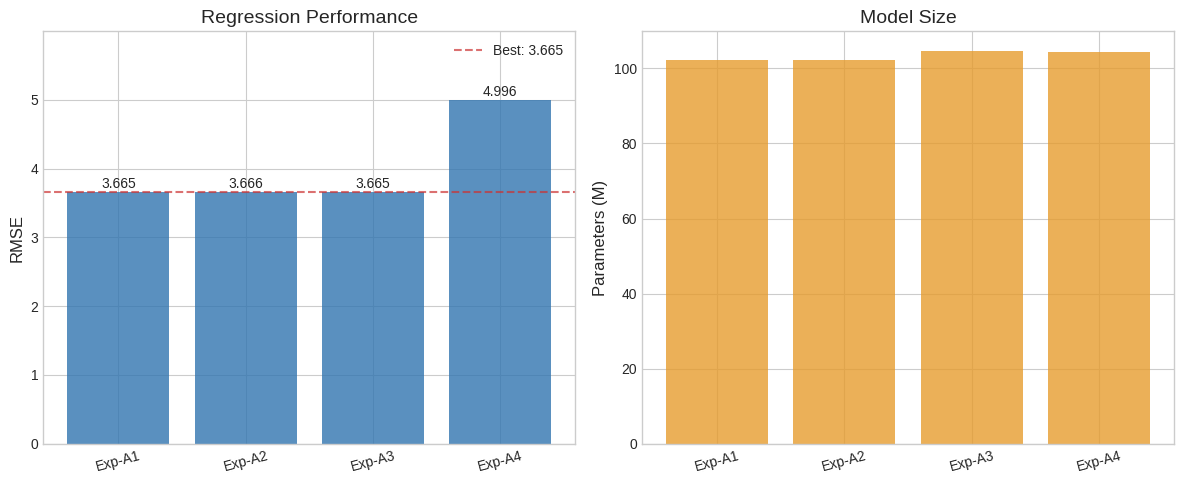

图片已保存至: /kaggle/working/phase1_groupA_results.png


In [50]:
import matplotlib.pyplot as plt
import numpy as np


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 图1: RMSE 对比
x = np.arange(len(df))
bars = ax1.bar(df['实验'], df['RMSE'], color=ACL_COLORS['blue'], alpha=0.8)
for bar, rmse in zip(bars, df['RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rmse:.3f}', ha='center', va='bottom', fontsize=10)

best_idx = df['RMSE'].idxmin()
ax1.axhline(y=df.loc[best_idx, 'RMSE'], color=ACL_COLORS['red'],
            linestyle='--', alpha=0.7, label=f"Best: {df.loc[best_idx, 'RMSE']:.3f}")
ax1.set_ylabel('RMSE')
ax1.set_title('Regression Performance')
ax1.set_ylim(0, df['RMSE'].max() * 1.2)
ax1.tick_params(axis='x', rotation=15)
ax1.legend()

# 图2: 参数量对比
ax2.bar(df['实验'], df['参数量(M)'], color=ACL_COLORS['orange'], alpha=0.8)
ax2.set_ylabel('Parameters (M)')
ax2.set_title('Model Size')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "phase1_groupA_results.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"图片已保存至: {PROJECT_ROOT / 'phase1_groupA_results.png'}")

In [51]:
print("""
========================================
Phase 1 Group A 实验结论
========================================

实验配置:
- 数据集: zho_restaurant (繁体中文餐厅评论)
- 任务: DimASR (给定文本+方面词, 预测VA分数)
- 损失函数: MSE
- 优化器: AdamW wd=0.01, 差分lr (backbone 2e-5 / head 1e-3) + warmup 10% 线性衰减 (Group C 标准)

实验结果对比:
""")
print(df.to_string(index=False))

print(f"""
最佳模型: {df.loc[df['RMSE'].idxmin(), '实验']} (RMSE={df['RMSE'].min():.4f})

观察:
1. Chinese-RoBERTa vs Chinese-BERT: RoBERTa 通常效果更好
2. CNN/LSTM 增强: 可捕获局部/序列特征
3. 参数量对比: CNN/LSTM 模型参数量更大

下一步建议:
- 尝试 Group B (LoRA/P-Tuning) 进行参数高效微调
- 尝试 Group C (SFT) 使用指令微调
""")


Phase 1 Group A 实验结论

实验配置:
- 数据集: zho_restaurant (繁体中文餐厅评论)
- 任务: DimASR (给定文本+方面词, 预测VA分数)
- 损失函数: MSE
- 优化器: AdamW (lr=2e-5)

实验结果对比:

    实验              模型   方法   RMSE  参数量(M)
Exp-A1    Chinese-BERT base 3.6649  102.27
Exp-A2 Chinese-RoBERTa base 3.6656  102.27
Exp-A3 Chinese-RoBERTa  cnn 3.6651  104.63
Exp-A4 Chinese-RoBERTa lstm 4.9963  104.37

最佳模型: Exp-A1 (RMSE=3.6649)

观察:
1. Chinese-RoBERTa vs Chinese-BERT: RoBERTa 通常效果更好
2. CNN/LSTM 增强: 可捕获局部/序列特征
3. 参数量对比: CNN/LSTM 模型参数量更大

下一步建议:
- 尝试 Group B (LoRA/P-Tuning) 进行参数高效微调
- 尝试 Group C (SFT) 使用指令微调

